# 02 — Xây dựng đặc trưng khách hàng không rò rỉ dữ liệu

Các đặc trưng được tạo tại một mốc chấm điểm khai báo trước. Giai đoạn phát triển dùng giao dịch đến hết **31 tháng 8 năm 2010**; tháng 9–10 là giai đoạn xác thực. Sau khi khóa thiết kế mô hình, lần huấn luyện cuối dùng giao dịch đến hết **31 tháng 10 năm 2010**; giai đoạn 1 tháng 11–9 tháng 12 được giữ kín cho đến notebook báo cáo kinh doanh.


In [1]:
from pathlib import Path
import json, os, warnings
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "online_retail_II.csv"
OUT = ROOT / "outputs"
INTERMEDIATE = OUT / "intermediate"
REPORTS = OUT / "reports"
FIGURES = OUT / "figures"
MODELS = OUT / "models"
for directory in (INTERMEDIATE, REPORTS, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)
(ROOT / "experiments").mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEV_CUTOFF = pd.Timestamp("2010-08-31 23:59:59")
VALIDATION_END = pd.Timestamp("2010-10-31 23:59:59")
HOLDOUT_END = pd.Timestamp("2010-12-09 23:59:59")
print(f"Thư mục gốc dự án: {ROOT}")


def build_customer_features(transactions, cutoff):
    d = transactions.loc[transactions["InvoiceDate"] <= cutoff].copy()
    invoice = (d.groupby(["Customer ID", "Invoice"], as_index=False)
                 .agg(InvoiceDate=("InvoiceDate", "min"),
                      OrderValue=("LineRevenue", "sum"),
                      BasketQuantity=("Quantity", "sum"),
                      BasketProducts=("StockCode", "nunique")))
    base = invoice.groupby("Customer ID").agg(
        LastPurchase=("InvoiceDate", "max"),
        FirstPurchase=("InvoiceDate", "min"),
        Frequency=("Invoice", "nunique"),
        Monetary=("OrderValue", "sum"),
        AOV=("OrderValue", "mean"),
        AvgBasketSize=("BasketQuantity", "mean"),
    )
    base["Recency"] = (cutoff.normalize() + pd.Timedelta(days=1) - base["LastPurchase"].dt.normalize()).dt.days
    base["ActiveDays"] = (base["LastPurchase"].dt.normalize() - base["FirstPurchase"].dt.normalize()).dt.days
    base["IsRepeat"] = (base["Frequency"] > 1).astype(int)
    diversity = d.groupby("Customer ID")["StockCode"].nunique().rename("ProductDiversity")
    base = base.join(diversity)
    base["PurchaseCadence"] = np.where(
        base["IsRepeat"].eq(1), base["ActiveDays"] / (base["Frequency"] - 1), np.nan
    )
    return base.drop(columns=["LastPurchase", "FirstPurchase"]).sort_index()


def future_outcomes(transactions, start, end, eligible_customers):
    future = transactions.loc[(transactions["InvoiceDate"] > start) & (transactions["InvoiceDate"] <= end)].copy()
    outcome = future.groupby("Customer ID").agg(
        FutureRevenue=("LineRevenue", "sum"),
        FutureOrders=("Invoice", "nunique"),
    )
    result = pd.DataFrame(index=pd.Index(eligible_customers, name="Customer ID")).join(outcome).fillna(0)
    result["FutureActive"] = (result["FutureOrders"] > 0).astype(int)
    return result

Thư mục gốc dự án: C:\Users\lqb46\Documents\Projects\Clustomer


## 1. Nạp quần thể đã được EDA phê duyệt

In [2]:
tx = pd.read_csv(INTERMEDIATE / "uk_completed_purchases.csv", parse_dates=["InvoiceDate"])
assert tx["Country"].eq("United Kingdom").all()
assert tx["Customer ID"].notna().all() and (tx["Quantity"] > 0).all() and (tx["Price"] > 0).all()
print(f"Giao dịch mua đã duyệt: {len(tx):,}; khách hàng: {tx['Customer ID'].nunique():,}")

Giao dịch mua đã duyệt: 364,233; khách hàng: 3,969


## 2. Định nghĩa đặc trưng và ý nghĩa của giá trị thiếu

In [3]:
dev = build_customer_features(tx, DEV_CUTOFF)
final_train = build_customer_features(tx, VALIDATION_END)
validation = future_outcomes(tx, DEV_CUTOFF, VALIDATION_END, dev.index)
print(f"Ma trận phát triển: {dev.shape}; ma trận huấn luyện cuối: {final_train.shape}")
display(dev.head(), dev.describe(percentiles=[.5,.9,.95,.99]).T)

Ma trận phát triển: (3065, 9); ma trận huấn luyện cuối: (3624, 9)


,Frequency,Monetary,AOV,AvgBasketSize,Recency,ActiveDays,IsRepeat,ProductDiversity,PurchaseCadence
Customer ID,,,,,,,,,
12346,11,372.860,33.896,6.364,65,196,1,26,19.600
12745,2,723.850,361.925,233.500,22,88,1,20,88.000
12746,1,254.550,254.550,97.000,76,0,0,17,NaN
12747,12,"3,259.970",271.664,74.333,5,263,1,59,23.909
12748,71,"11,327.720",159.545,64.662,17,254,1,742,3.629


,count,mean,std,min,50%,90%,95%,99%,max
Frequency,"3,065.000",3.610,5.729,1.000,2.000,7.000,10.000,25.360,85.000
Monetary,"3,065.000","1,491.545","6,104.266",2.950,575.540,"2,782.322","4,611.662","15,141.250","269,041.670"
AOV,"3,065.000",342.474,414.644,2.950,276.500,599.652,799.805,"1,629.245","10,953.500"
AvgBasketSize,"3,065.000",210.143,470.345,1.000,142.500,391.400,549.571,"1,055.269","17,766.000"
Recency,"3,065.000",91.479,74.856,1.000,73.000,207.200,258.000,272.000,274.000
ActiveDays,"3,065.000",87.528,92.539,0.000,62.000,236.000,253.800,266.000,273.000
IsRepeat,"3,065.000",0.616,0.486,0.000,1.000,1.000,1.000,1.000,1.000
ProductDiversity,"3,065.000",52.362,67.788,1.000,32.000,122.000,171.000,315.720,"1,241.000"
PurchaseCadence,"1,888.000",55.897,43.940,0.000,45.708,115.150,142.650,217.260,263.000


`PurchaseCadence` không xác định, chứ không bằng 0, đối với khách hàng chỉ có một đơn hàng. `IsRepeat` thể hiện trạng thái đó một cách tường minh. Giá trị gốc vẫn được giữ để lập hồ sơ; các đặc trưng ứng viên cho mô hình dùng `log1p` rồi chuẩn hóa, trong đó bộ chuẩn hóa chỉ được khớp trên quần thể phát triển.


In [4]:
missing = pd.DataFrame({"missing_n": dev.isna().sum(), "missing_pct": dev.isna().mean()*100})
display(missing[missing.missing_n > 0])
assert dev.loc[dev["IsRepeat"].eq(0), "PurchaseCadence"].isna().all()

,missing_n,missing_pct
PurchaseCadence,1177,38.401


## 3. Phân phối, mức độ trùng thông tin và các bộ đặc trưng ứng viên

,raw_skew,log1p_skew
Recency,0.800,-0.759
Frequency,7.593,1.313
Monetary,30.527,0.207
AOV,13.144,-0.414
AvgBasketSize,27.288,-0.705
ActiveDays,0.540,-0.231
ProductDiversity,5.021,-0.293
PurchaseCadence,1.543,-1.569


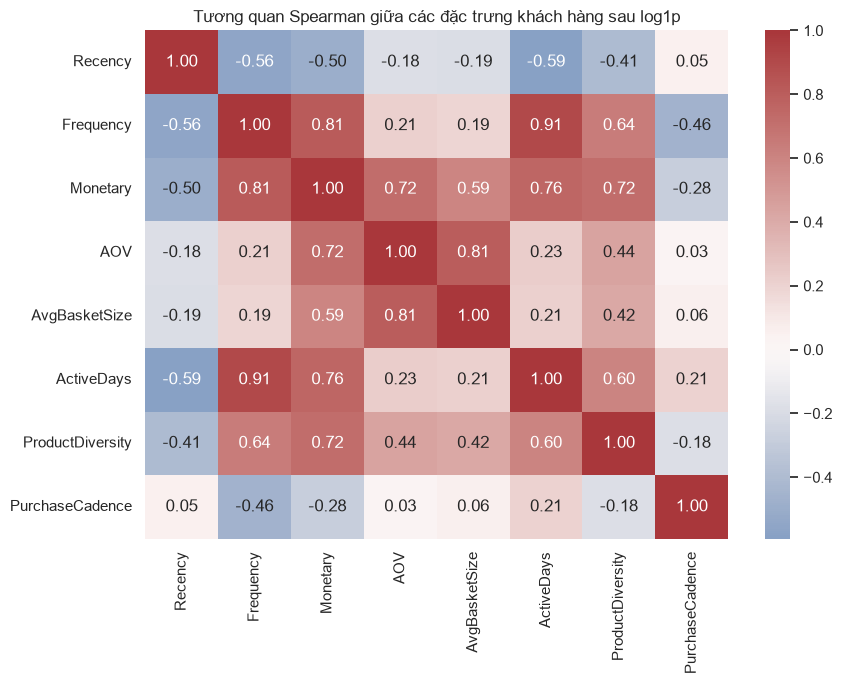

In [5]:
numeric = ["Recency","Frequency","Monetary","AOV","AvgBasketSize","ActiveDays","ProductDiversity","PurchaseCadence"]
skew = pd.DataFrame({"raw_skew": dev[numeric].skew(), "log1p_skew": np.log1p(dev[numeric]).skew()})
display(skew)
corr = np.log1p(dev[numeric]).corr(method="spearman")
plt.figure(figsize=(9,7)); sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Tương quan Spearman giữa các đặc trưng khách hàng sau log1p"); plt.tight_layout(); plt.show()

In [6]:
feature_sets = {
    "core_rfm": ["Recency", "Frequency", "Monetary"],
    "behavioral": ["Recency", "Frequency", "Monetary", "AOV", "AvgBasketSize", "ProductDiversity"],
}
for name, cols in feature_sets.items():
    assert np.isfinite(np.log1p(dev[cols]).to_numpy()).all()
    print(name, cols)

core_rfm ['Recency', 'Frequency', 'Monetary']
behavioral ['Recency', 'Frequency', 'Monetary', 'AOV', 'AvgBasketSize', 'ProductDiversity']


`ActiveDays` bị loại vì một phần phản ánh thời gian gắn bó của khách hàng và luôn bằng 0 đối với khách hàng chỉ có một đơn hàng. `PurchaseCadence` chỉ phục vụ kiểm định vì không xác định cho khách hàng mua một lần. `IsRepeat` là quy tắc suy ra trực tiếp từ `Frequency`, nên sẽ lặp lại thông tin. Bộ đặc trưng mở rộng chỉ được giữ để kiểm tra liệu chi tiết hành vi bổ sung có cải thiện độ ổn định và khả năng phân tách hành vi tương lai hay không.


## 4. Kết quả giai đoạn xác thực — tuyệt đối không dùng làm đầu vào phân cụm

In [7]:
display(validation.describe().T)
print(f"Tỷ lệ mua lại trong giai đoạn xác thực: {validation['FutureActive'].mean():.2%}")
print(f"Doanh thu trong giai đoạn xác thực: £{validation['FutureRevenue'].sum():,.2f}")
assert validation.index.equals(dev.index)

,count,mean,std,min,25%,50%,75%,max
FutureRevenue,"3,065.000",399.496,"1,244.564",0.000,0.000,0.000,425.640,"30,195.560"
FutureOrders,"3,065.000",0.891,1.760,0.000,0.000,0.000,1.000,40.000
FutureActive,"3,065.000",0.470,0.499,0.000,0.000,0.000,1.000,1.000


Tỷ lệ mua lại trong giai đoạn xác thực: 47.05%
Doanh thu trong giai đoạn xác thực: £1,224,455.89


In [8]:
dev.to_csv(INTERMEDIATE / "development_features.csv")
validation.to_csv(INTERMEDIATE / "validation_outcomes.csv")
final_train.to_csv(INTERMEDIATE / "final_train_features.csv")
contract = {
    "entity": "Customer ID", "population": "Khách hàng đã định danh tại Vương quốc Anh với giao dịch mua hoàn tất và giá trị dương",
    "development_cutoff": str(DEV_CUTOFF), "validation_end": str(VALIDATION_END),
    "holdout_end": str(HOLDOUT_END), "candidate_feature_sets": feature_sets,
    "audit_only": ["ActiveDays", "PurchaseCadence", "IsRepeat"],
    "transform": "log1p, sau đó StandardScaler được khớp trên quần thể huấn luyện",
}
(REPORTS / "feature_contract.json").write_text(json.dumps(contract, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(contract, indent=2, ensure_ascii=False))

{
  "entity": "Customer ID",
  "population": "Khách hàng đã định danh tại Vương quốc Anh với giao dịch mua hoàn tất và giá trị dương",
  "development_cutoff": "2010-08-31 23:59:59",
  "validation_end": "2010-10-31 23:59:59",
  "holdout_end": "2010-12-09 23:59:59",
  "candidate_feature_sets": {
    "core_rfm": [
      "Recency",
      "Frequency",
      "Monetary"
    ],
    "behavioral": [
      "Recency",
      "Frequency",
      "Monetary",
      "AOV",
      "AvgBasketSize",
      "ProductDiversity"
    ]
  },
  "audit_only": [
    "ActiveDays",
    "PurchaseCadence",
    "IsRepeat"
  ],
  "transform": "log1p, sau đó StandardScaler được khớp trên quần thể huấn luyện"
}


## Quyết định xây dựng đặc trưng

Hai ma trận ứng viên được đưa sang bước thử nghiệm: RFM cốt lõi, dễ diễn giải và một bộ hành vi mở rộng. Kết quả tương lai được tách khỏi đầu vào mô hình, chỉ dùng để kiểm tra liệu các phân khúc có phân tách được hành vi khách hàng ở giai đoạn sau hay không. Notebook này chưa tổng hợp hoặc xem dữ liệu của tập kiểm định cuối.
